In [17]:
"""
halflife_vs_T.py
================
Plot half-life of β-carotene as a function of equilibrium temperature,
using Arrhenius parameters from thermal degradation experiments.

Physical model:
  - First-order decay kinetics: k(T) = A * exp(-Ea/RT)
  - Half-life: t_1/2 = ln(2) / k(T)
  - Arrhenius parameters derived from measurements at 150°C and 300°C
  - Extrapolated to post-main-sequence temperatures

Colour palette (group standard):
  - Peak: orange (#ffa600)
  - AUC:  teal (#007d67)
"""

import numpy as np
import matplotlib.pyplot as plt

In [18]:
# ============================================================================
# CONSTANTS & PARAMETERS
# ============================================================================

# Gas constant
R = 8.314  # J/(mol·K)

# 6-colour palette
PALETTE = {
    "dark":   "#003d5c",
    "teal1":  "#005d71",
    "teal2":  "#007d67",
    "green":  "#1a983f",
    "olive":  "#92a800",
    "orange": "#ffa600",
}

# Arrhenius parameters (β-carotene, this work)
# Peak absorbance (450–550 nm)
EA_PEAK = 17.6e3    # J/mol
A_PEAK = 2.8e-2     # s^-1
SEA_PEAK = 2.3e3    # J/mol (1σ uncertainty)

# Integrated area under curve (200–700 nm)
EA_AUC = 13.9e3     # J/mol
A_AUC = 3.9e-3      # s^-1
SEA_AUC = 1.6e3     # J/mol (1σ uncertainty)

# Measured temperature range (marked on plot)
T_MIN_MEAS = 150 + 273.15  # K
T_MAX_MEAS = 300 + 273.15  # K

# ============================================================================
# FUNCTIONS
# ============================================================================

def halflife(T, Ea, A):
    """
    Half-life from first-order decay kinetics.
    
    Parameters:
    -----------
    T : float or ndarray
        Temperature (K)
    Ea : float
        Activation energy (J/mol)
    A : float
        Pre-exponential factor (s^-1)
    
    Returns:
    --------
    t_half : float or ndarray
        Half-life (seconds)
    
    Formula:
        k(T) = A * exp(-Ea / RT)
        t_1/2 = ln(2) / k(T)
    """
    k = A * np.exp(-Ea / (R * T))
    return np.log(2) / k


def halflife_uncertainty(T, Ea, SEa, A):
    """
    Compute upper and lower bounds of half-life (Ea ± 1σ).
    
    Returns:
    --------
    t_lo, t_hi : ndarray, ndarray
        Half-life at Ea + SEa and Ea - SEa respectively.
    """
    t_lo = halflife(T, Ea + SEa, A)
    t_hi = halflife(T, Ea - SEa, A)
    return t_lo, t_hi


In [19]:
# ============================================================================
# MAIN PLOT
# ============================================================================

def main():
    # Temperature range for plotting
    T_plot = np.linspace(250, 2000, 300)  # K
    
    # Compute half-lives (convert seconds to hours)
    t_half_peak = halflife(T_plot, EA_PEAK, A_PEAK) / 3600
    t_half_auc = halflife(T_plot, EA_AUC, A_AUC) / 3600
    
    # Compute uncertainty bands
    t_peak_lo, t_peak_hi = halflife_uncertainty(T_plot, EA_PEAK, SEA_PEAK, A_PEAK)
    t_peak_lo, t_peak_hi = t_peak_lo / 3600, t_peak_hi / 3600
    
    t_auc_lo, t_auc_hi = halflife_uncertainty(T_plot, EA_AUC, SEA_AUC, A_AUC)
    t_auc_lo, t_auc_hi = t_auc_lo / 3600, t_auc_hi / 3600
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(11, 6.5))
    
    # ---- Plot half-life curves with uncertainty bands ----
    
    # AUC (teal, dashed line)
    ax.fill_between(T_plot, t_auc_lo, t_auc_hi, 
                    color=PALETTE["teal2"], alpha=0.15, zorder=1, label=None)
    ax.plot(T_plot, t_half_auc, color=PALETTE["teal2"], linestyle="--", lw=2.2, 
            label=f"AUC ($E_a$=13.9 kJ/mol)", zorder=3)
    
    # Peak (orange, solid line)
    ax.fill_between(T_plot, t_peak_lo, t_peak_hi, 
                    color=PALETTE["orange"], alpha=0.15, zorder=2, label=None)
    ax.plot(T_plot, t_half_peak, color=PALETTE["orange"], linestyle="-", lw=2.2, 
            label=f"Peak ($E_a$=17.6 kJ/mol)", zorder=4)
    
    # ---- Reference timescales (horizontal lines) ----
    timescale_refs = [
        (1, "1 hour"),
        (24, "1 day"),
        #(365.25 * 24, "1 year"),
        #(1e6 * 365.25 * 24, "1 Myr"),
    ]
    
    for t_ref, label in timescale_refs:
        ax.axhline(t_ref, color="grey", linestyle=":", lw=0.8, alpha=0.5, zorder=0)
        ax.text(2000, t_ref * 1.0, label, fontsize=12, color="grey", 
                va="bottom", ha="right")
    
    # ---- Measured temperature range (shaded) ----
    ax.axvspan(T_MIN_MEAS, T_MAX_MEAS, color="lightgrey", alpha=0.3, zorder=0)
    ax.text((T_MIN_MEAS + T_MAX_MEAS) / 2, 3e1, "Measured\nRange", 
            fontsize=10, ha="center", va="center", color="#555555", style="italic")
    
    # ---- Axes configuration ----
    ax.set_xlabel("Equilibrium temperature (K)", fontsize=14)
    ax.set_ylabel("$\\beta$-carotene half-life (hours)", fontsize=14)
    ax.set_yscale("log")
    ax.set_xlim(250, 2050)
    ax.set_ylim(1e-1, 1e3)
    
    # ---- Grid and legend ----
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(fontsize=14, loc="upper right", framealpha=0.95, edgecolor="lightgrey")
    
    # ---- Layout and save ----
    fig.tight_layout()
    plt.savefig("halflife.png", dpi=300, bbox_inches="tight")
    print("✓ Saved: halflife_vs_T.png")
    plt.show()





Half-life calculations (β-carotene thermal degradation)
T (K)      T (°C)     t_1/2 peak (h)       t_1/2 AUC (h)        Ratio     
------------------------------------------------------------------------------------------
423        150        1.023e+00            2.567e+00            0.399     
473        200        6.032e-01            1.691e+00            0.357     
523        250        3.933e-01            1.206e+00            0.326     
573        300        2.763e-01            9.126e-01            0.303     
673        400        1.596e-01            5.917e-01            0.270     
773        500        1.063e-01            4.291e-01            0.248     
1273       1000       3.626e-02            1.836e-01            0.198     

✓ Saved: halflife_vs_T.png


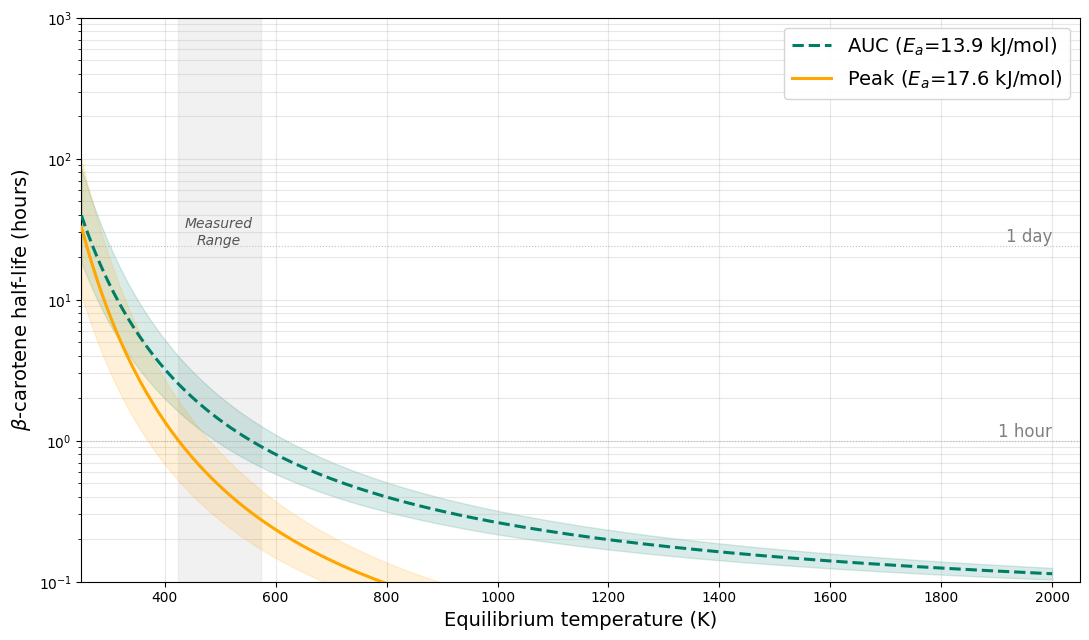

In [20]:
# ============================================================================
# CONSOLE OUTPUT (validation table)
# ============================================================================

def print_summary():
    """Print half-life values at selected temperatures."""
    print("\n" + "="*90)
    print("Half-life calculations (β-carotene thermal degradation)")
    print("="*90)
    print(f"{'T (K)':<10} {'T (°C)':<10} {'t_1/2 peak (h)':<20} {'t_1/2 AUC (h)':<20} {'Ratio':<10}")
    print("-"*90)
    
    temps_K = [150 + 273.15, 200 + 273.15, 250 + 273.15, 300 + 273.15, 
               400 + 273.15, 500 + 273.15, 1000 + 273.15]
    
    for T_K in temps_K:
        T_C = T_K - 273.15
        t_peak_h = halflife(T_K, EA_PEAK, A_PEAK) / 3600
        t_auc_h = halflife(T_K, EA_AUC, A_AUC) / 3600
        ratio = t_peak_h / t_auc_h
        print(f"{T_K:<10.0f} {T_C:<10.0f} {t_peak_h:<20.3e} {t_auc_h:<20.3e} {ratio:<10.3f}")
    
    print("="*90 + "\n")


# ============================================================================
# ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    print_summary()
    main()